# Polar Plot Performance

In ADF we have been making contour plots with polar plots, but they are very slow. Here we examine options to improve performance.

CPU times: user 3.17 s, sys: 532 ms, total: 3.7 s
Wall time: 5.19 s


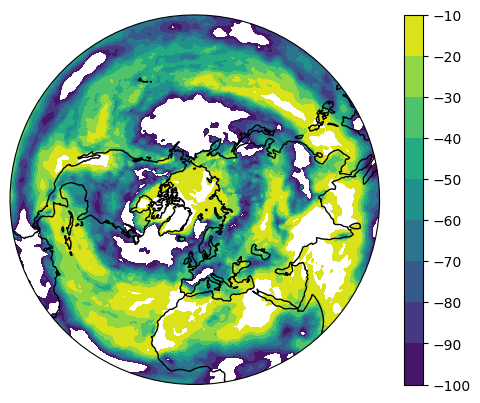

In [1]:
%%time
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

fil = "/Users/brianpm/Documents/cesm2_lens_data/SWCF/b.e21.BHISTsmbb.f09_g17.LE2-1151.008.cam.h0.SWCF.188001-188912.nc"

ds = xr.open_dataset(fil).isel(time=100)

x = ds['SWCF']

# Reduce to desired hemisphere
# ADD CYCLIC POINT
# USE MESHGRID
# CONTOURF
# projection: ccrs.NorthPolarStereo
# trim to circular boundary

x_nh = x.sel(lat=slice(0,90))

x_cyclic, lon_cyclic = add_cyclic_point(x_nh, coord=x.lon)


lons, lats = np.meshgrid(lon_cyclic, x_nh.lat)


levels = np.arange(-100, 0, 10)

proj = ccrs.NorthPolarStereo()
# proj = ccrs.Stereographic(false_northing=30000.0)
fig, ax = plt.subplots(subplot_kw={"projection":proj})
img1 = ax.contourf(lons, lats, x_cyclic, levels=levels, transform=ccrs.PlateCarree())
ax.coastlines()
fig.colorbar(img1, ax=ax)

# __Follow the cartopy gallery example to make circular__:
# Compute a circle in axes coordinates, which we can use as a boundary
# for the map. We can pan/zoom as much as we like - the boundary will be
# permanently circular.
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpl.path.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

In [ ]:


x

In [ ]:
%%time



In [ ]:
%%time

# ADD CYCLIC POINT
# USE MESHGRID
# PCOLORMESH
# ccrs.NorthPolarStereo

x_nh = x.sel(lat=slice(0,90))

x_cyclic, lon_cyclic = add_cyclic_point(x_nh, coord=x.lon)


lons, lats = np.meshgrid(lon_cyclic, x_nh.lat)


levels = np.arange(-100, 0, 10)

proj = ccrs.NorthPolarStereo()
# proj = ccrs.Stereographic(false_northing=30000.0)
fig, ax = plt.subplots(subplot_kw={"projection":proj})
img1 = ax.pcolormesh(lons, lats, x_cyclic, transform=ccrs.PlateCarree())
ax.coastlines()
fig.colorbar(img1, ax=ax)

# __Follow the cartopy gallery example to make circular__:
# Compute a circle in axes coordinates, which we can use as a boundary
# for the map. We can pan/zoom as much as we like - the boundary will be
# permanently circular.
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpl.path.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
ax.set_extent([0, 360, 0, 90], crs=ccrs.PlateCarree())

In [ ]:
%%time

# ADD CYCLIC POINT
# USE MESHGRID
# PCOLORMESH
# ccrs.Stereographic

x_nh = x.sel(lat=slice(0,90))

x_cyclic, lon_cyclic = add_cyclic_point(x_nh, coord=x.lon)


lons, lats = np.meshgrid(lon_cyclic, x_nh.lat)


levels = np.arange(-100, 0, 10)

proj = ccrs.Stereographic(central_latitude=90.0, central_longitude=0.0)
# proj = ccrs.Stereographic(false_northing=30000.0)
fig, ax = plt.subplots(subplot_kw={"projection":proj})
img1 = ax.pcolormesh(lons, lats, x_cyclic, transform=ccrs.PlateCarree())
ax.coastlines()
fig.colorbar(img1, ax=ax)

# __Follow the cartopy gallery example to make circular__:
# Compute a circle in axes coordinates, which we can use as a boundary
# for the map. We can pan/zoom as much as we like - the boundary will be
# permanently circular.
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpl.path.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

ax.set_extent([0, 360, 0, 90], crs=ccrs.PlateCarree())

In [ ]:
%%time

x_nh = x.sel(lat=slice(0,90))

x_cyclic, lon_cyclic = add_cyclic_point(x_nh, coord=x.lon)

lons, lats = np.meshgrid(lon_cyclic, x_nh.lat)



proj = ccrs.NorthPolarStereo()

coord_prj = proj.transform_points(ccrs.PlateCarree(), lons, lats)
print(coord_prj.shape)
levels = np.arange(-100, 0, 10)

fig, ax = plt.subplots(subplot_kw={"projection":proj})
fill_c = ax.contourf(lons, lats, x_cyclic, levels=levels, transform=ccrs.PlateCarree())
# line_c = ax.contour(lons, lats, x_cyclic, levels=levels, transform=ccrs.PlateCarree(), colors='none', linestyles='solid')
# # Use the line contours to place contour labels.
# ax.clabel(
#     line_c,  # Typically best results when labelling line contours.
#     colors=['black'],
#     manual=False,  # Automatic placement vs manual placement.
#     inline=True,  # Cut the line where the label will be placed.
#     fmt=' {:.0f} '.format,  # Labes as integers, with some extra space.
# )
ax.coastlines()
fig.colorbar(fill_c, ax=ax)

# __Follow the cartopy gallery example to make circular__:
# Compute a circle in axes coordinates, which we can use as a boundary
# for the map. We can pan/zoom as much as we like - the boundary will be
# permanently circular.
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpl.path.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)


In [ ]:
%%time
import numpy as np
import xarray as xr
import plotly.graph_objects as go
import plotly.express as px
from cartopy.util import add_cyclic_point

# Load your data (same as before)
fil = "/Users/brianpm/Documents/cesm2_lens_data/SWCF/b.e21.BHISTsmbb.f09_g17.LE2-1151.008.cam.h0.SWCF.188001-188912.nc"
ds = xr.open_dataset(fil).isel(time=100)
x = ds['SWCF']
x_nh = x.sel(lat=slice(0,90))

# Add cyclic point
x_cyclic, lon_cyclic = add_cyclic_point(x_nh, coord=x.lon)

# Create meshgrid
lons, lats = np.meshgrid(lon_cyclic, x_nh.lat)

# Convert to stereographic projection coordinates
def latlon_to_stereo(lat, lon):
    """Convert lat/lon to stereographic projection (North Pole)"""
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    
    # Stereographic projection formulas
    k = 2 / (1 + np.sin(lat_rad))
    x = k * np.cos(lat_rad) * np.sin(lon_rad)
    y = k * np.cos(lat_rad) * np.cos(lon_rad)
    
    return x, y

# Project coordinates
x_proj, y_proj = latlon_to_stereo(lats, lons)

# Define contour levels
levels = np.arange(-100, 0, 10)

# Create the contour plot
fig = go.Figure()

# Add filled contours
fig.add_trace(go.Contour(
    x=x_proj.flatten(),
    y=y_proj.flatten(), 
    z=x_cyclic.flatten(),
    contours=dict(
        start=-100,
        end=0,
        size=10,
        coloring='fill'
    ),
    colorscale='viridis',  # You can change this to match your preference
    showscale=True,
    colorbar=dict(title="SWCF")
))

# Add coastlines (simplified - you might want to load actual coastline data)
# For now, adding a circle at approximately 60N latitude as boundary
theta_boundary = np.linspace(0, 2*np.pi, 100)
boundary_lat = np.full_like(theta_boundary, 60)  # 60N latitude
boundary_lon = np.degrees(theta_boundary)
x_boundary, y_boundary = latlon_to_stereo(boundary_lat, boundary_lon)

fig.add_trace(go.Scatter(
    x=x_boundary,
    y=y_boundary,
    mode='lines',
    line=dict(color='black', width=1),
    showlegend=False,
    name='60N boundary'
))

# Set equal aspect ratio and clean layout
fig.update_layout(
    title="SWCF - North Polar Stereographic",
    xaxis=dict(
        scaleanchor="y",
        scaleratio=1,
        showgrid=False,
        zeroline=False,
        showticklabels=False
    ),
    yaxis=dict(
        showgrid=False,
        zeroline=False,
        showticklabels=False
    ),
    width=600,
    height=600,
    plot_bgcolor='white'
)

# Show the plot
fig.show()

# Alternative: Using Plotly's built-in polar projection (may be faster)
def create_polar_plot_builtin():
    """Alternative using Plotly's built-in polar coordinates"""
    
    # For polar plots, we need to convert to polar coordinates
    # This approach uses Plotly's native polar plotting
    
    fig_polar = go.Figure()
    
    # Convert lat/lon to polar coordinates (radius = 90-lat, theta = lon)
    r_vals = 90 - lats
    theta_vals = lons
    
    # Create polar contour (note: this requires some data reshaping)
    fig_polar.add_trace(go.Scatterpolar(
        r=r_vals.flatten(),
        theta=theta_vals.flatten(),
        mode='markers',
        marker=dict(
            size=2,
            color=x_cyclic.flatten(),
            colorscale='viridis',
            showscale=True,
            colorbar=dict(title='SWCF')
        )
    ))
    
    fig_polar.update_layout(
        title="SWCF - Polar Plot (Alternative)",
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 90]
            ),
            angularaxis=dict(
                direction='clockwise',
                period=360
            )
        )
    )
    
    return fig_polar

# Uncomment to try the alternative polar approach:
fig_polar = create_polar_plot_builtin()
fig_polar.show()